# Módulo 9 — LP de panel y evidencia narrativa (austeridad y Banxico)

**Curso complementario · puremacro · mazo Slides05 — identificación empírica (semanas 9–10)**

### Objetivos de aprendizaje
Al terminar esta lección podrás:
1. Estimar una **proyección local (LP) de panel** con **efectos fijos de dos vías**
   (país y tiempo) y **errores estándar Driscoll-Kraay (1998)**, robustos a la
   **dependencia transversal** y a la autocorrelación.
2. Medir el **multiplicador de la austeridad** con el diseño de las **consolidaciones
   fiscales narrativas** *action-based* de **Devries-Guajardo-Leigh-Pescatori (2011)**
   — sobre un panel **simulado** con esa estructura, porque el panel DGLP original no
   viene en el *bundle* (véase el aviso de la §2).
3. Leer e interpretar un **índice de postura por texto** —la postura mensual de
   **Banxico**, ya construida en el *bundle*— y relacionarla con la **actividad**.
4. Diagnosticar la **identificación en panel** (anticipación, choques comunes, DK vs
   cluster) y el problema de **instrumentos débiles** con la **F de primera etapa**.

Todo corre en Python puro sobre tu **instalación local** de `puremacro`
(`pip install puremacro`), con los datos congelados del *bundle*: sin conexión y sin costo.

> **Aviso de datos, de entrada.** Esta lección enseña el **método**, no publica
> estimaciones citables. Las dos aplicaciones se corren sobre datos **simulados y
> declarados**: el panel de 17 países de la §2 es un DGP con la estructura de DGLP, y la
> serie de actividad de la §3 es simulada (el índice de postura de Banxico **sí** es real).
> Ninguna cifra de aquí tiene por qué coincidir con las del mazo **Slides05**, que trabaja
> con los datos verdaderos; el mazo lo advierte explícitamente.

In [1]:
import sys, pathlib
import numpy as np, pandas as pd
import matplotlib
try:  # bajo Jupyter/ipykernel: conserva el backend inline (captura figuras)
    get_ipython()
except NameError:
    matplotlib.use("Agg")  # script plano / CLI: backend no interactivo
import matplotlib.pyplot as plt
_cwd = pathlib.Path.cwd()
_nb = _cwd if (_cwd / "_nbstyle.py").exists() else _cwd.parent
sys.path.insert(0, str(_nb)); sys.path.insert(0, str(_nb / "course"))
import _nbstyle; _nbstyle.apply_style()
from _tutor import tutor
DATA = (_nb / "course" / "data")

## 1. La LP de panel de dos vías

Con datos de $C$ países y $T$ trimestres, la proyección local de panel estima —para
cada horizonte $h$— el coeficiente $\beta_h$ de la respuesta acumulada del producto a
un choque $x_{c,t}$:

$$ y_{c,t+h} - y_{c,t-1} \;=\; \mu_c \;+\; \tau_t \;+\; \beta_h\, x_{c,t} \;+\; \gamma' Z_{c,t-1} \;+\; \varepsilon_{c,t+h}. $$

- $\mu_c$: **efecto fijo de país** — absorbe niveles y tendencias específicas de cada país.
- $\tau_t$: **efecto fijo de tiempo** — absorbe los **choques comunes** de cada trimestre
  (el ciclo global, la Gran Recesión, el COVID). Sin él, la identificación confunde el
  choque con lo que le pasa a todos a la vez.
- $\{\beta_h\}_{h=0}^{H}$ es la **función impulso-respuesta** (Jordà 2005): el efecto de
  $x$ sobre $y$ a cada horizonte, estimado con una regresión por horizonte.

### ¿Por qué Driscoll-Kraay?
El error $\varepsilon_{c,t+h}$ de una LP tiene **dos patologías**:
1. **Autocorrelación** inducida por el traslape: al proyectar a horizonte $h$, errores
   contiguos comparten choques (banda MA($h$)).
2. **Dependencia transversal**: aun con efectos de tiempo, los residuos de distintos
   países pueden co-moverse en un mismo trimestre (un choque global mal absorbido).

**Driscoll-Kraay (1998)** trata ambas: agrega las condiciones de momento **por periodo**
(suma transversal) y aplica un **kernel de Newey-West** (Bartlett) a esa serie temporal
—así resulta robusto a heteroscedasticidad, autocorrelación y correlación transversal.
En `puremacro` esto es `panel_lp_dk`; su hermano `panel_lp` usa errores
**cluster-robustos por país**. Ambos parten de la **transformación *within* de dos vías**.

In [2]:
from puremacro.lp import panel_lp, panel_lp_dk, lp_hac
# panel_lp(df_wide, y, x, horizons, n_lags, controls, alpha, entity_level, time_level)
#   -> DataFrame[h, beta, se, t, lo, hi]   (efectos fijos de dos vías; SE cluster por país)
# panel_lp_dk(...)  -> misma firma, pero SE Driscoll-Kraay (1998)
# lp_hac(df, y, x, ...) -> LP de un solo país con SE Newey-West (banda h+1)

## 2. La austeridad como choque narrativo (Devries et al. 2011)

El problema clásico de los multiplicadores fiscales es la **endogeneidad**: los déficits
suben en las recesiones *por* la recesión (estabilizadores automáticos), así que una
regresión ingenua confunde causa y efecto. La solución **narrativa** de
**Devries-Guajardo-Leigh-Pescatori (2011, IMF WP/11/128)** codifica a mano, leyendo
presupuestos y discursos, las consolidaciones **motivadas por reducir el déficit** (no
por el ciclo) — el conjunto *action-based* de **17 economías avanzadas**
(AUS, AUT, BEL, CAN, DNK, FIN, FRA, DEU, IRL, ITA, JPN, NLD, PRT, ESP, SWE, GBR, USA),
con la **magnitud en % del PIB** de cada episodio.

> **Datos.** El panel DGLP original **no viene** en `DATA/*.csv` de este bundle. Para no
> salir a la red, **simulamos** un panel con la misma estructura (17 países, episodios de
> consolidación dispersos en % del PIB) y **lo declaramos**. El bundle sí trae
> `tax14_narrative_tax_shocks.csv` (choques narrativos de EE. UU., Romer-Romer +
> Mertens-Ravn) como análogo de **una sola** economía.

In [3]:
# --- PANEL SIMULADO (declarado): consolidaciones fiscales narrativas estilo DGLP ---
rng = np.random.default_rng(20260721)
paises = "AUS AUT BEL CAN DNK FIN FRA DEU IRL ITA JPN NLD PRT ESP SWE GBR USA".split()
T = 80                                                   # 2000Q1..2019Q4
fechas = pd.period_range("2000Q1", periods=T, freq="Q").to_timestamp()
comun = np.cumsum(rng.normal(0.0, 0.6, T))               # ciclo global -> lo absorbe el efecto de tiempo

def irf_true(h):                                         # multiplicador "verdadero" del DGP (declarado)
    return -1.3 * (1.0 - np.exp(-(h + 1) / 3.0))         # % de PIB por 1% de PIB de consolidación

filas = []
for c in paises:
    trend = rng.uniform(0.3, 0.6); nivel0 = rng.uniform(90, 110)
    z = np.where(rng.random(T) < 0.09, rng.gamma(2.0, 0.5, T), 0.0)   # consolidaciones (% PIB), dispersas y positivas
    eps = np.zeros(T)
    for t in range(1, T):
        eps[t] = 0.6 * eps[t - 1] + rng.normal(0, 0.4)               # componente idiosincrático AR(1)
    contrib = np.array([sum(irf_true(t - s) * z[s] for s in range(t + 1)) for t in range(T)])
    y = nivel0 + trend * np.arange(T) + comun + eps + contrib        # y == 100*log(PIB): beta_h queda en %
    filas += [(c, fechas[t], y[t], z[t]) for t in range(T)]

panel = (pd.DataFrame(filas, columns=["code", "date", "logY100", "cons"])
           .set_index(["code", "date"]))                             # MultiIndex (país, tiempo) requerido
print(f"panel simulado: {len(paises)} países x {T} trimestres = {len(panel):,} celdas")
print(f"episodios de consolidación (cons>0): {int((panel['cons'] > 0).sum())}")

panel simulado: 17 países x 80 trimestres = 1,360 celdas
episodios de consolidación (cons>0): 114


### Estimación: DK vs cluster
Corremos la LP de panel a horizontes $h=0,\dots,12$ con dos rezagos de control. La
variable dependiente $y$ es $100\cdot\log(\text{PIB})$, de modo que $\beta_h$ está en
**puntos porcentuales por 1% del PIB** de consolidación (el signo negativo = la
austeridad **contrae** el producto).

In [4]:
H = range(0, 13)
dk = panel_lp_dk(panel, y="logY100", x="cons", horizons=H, n_lags=2)   # Driscoll-Kraay
cl = panel_lp(panel,    y="logY100", x="cons", horizons=H, n_lags=2)   # cluster por país

tab = dk[["h", "beta", "se"]].rename(columns={"se": "se_DK"}).copy()
tab["se_cluster"] = cl["se"].values
tab["IRF_verdadera"] = [irf_true(h) for h in H]
print("Multiplicador de la austeridad — PANEL SIMULADO (LP de panel, EF de dos vías).")
print("No son estimaciones de los datos DGLP reales; la columna IRF_verdadera es el DGP.")
print(tab.round(3).to_string(index=False))

pico = dk.loc[dk["beta"].idxmin()]
razon_se = float(dk["se"].mean() / cl["se"].mean())
print(f"\npico: beta = {pico['beta']:.2f} en h = {int(pico['h'])} trimestres")
print(f"razón SE (DK / cluster), promedio sobre h: {razon_se:.2f}")
assert dk["beta"].min() < -0.5          # la austeridad contrae el producto
assert (dk["se"] > 0).all()

Multiplicador de la austeridad — PANEL SIMULADO (LP de panel, EF de dos vías).
No son estimaciones de los datos DGLP reales; la columna IRF_verdadera es el DGP.
 h   beta  se_DK  se_cluster  IRF_verdadera
 0 -0.348  0.040       0.030         -0.369
 1 -0.494  0.082       0.053         -0.633
 2 -0.704  0.079       0.049         -0.822
 3 -0.704  0.085       0.071         -0.957
 4 -0.849  0.089       0.095         -1.054
 5 -0.897  0.095       0.096         -1.124
 6 -0.993  0.098       0.079         -1.174
 7 -0.944  0.114       0.083         -1.210
 8 -0.928  0.146       0.092         -1.235
 9 -0.882  0.095       0.075         -1.254
10 -0.839  0.097       0.099         -1.267
11 -0.786  0.114       0.099         -1.276
12 -0.817  0.125       0.101         -1.283

pico: beta = -0.99 en h = 6 trimestres
razón SE (DK / cluster), promedio sobre h: 1.23


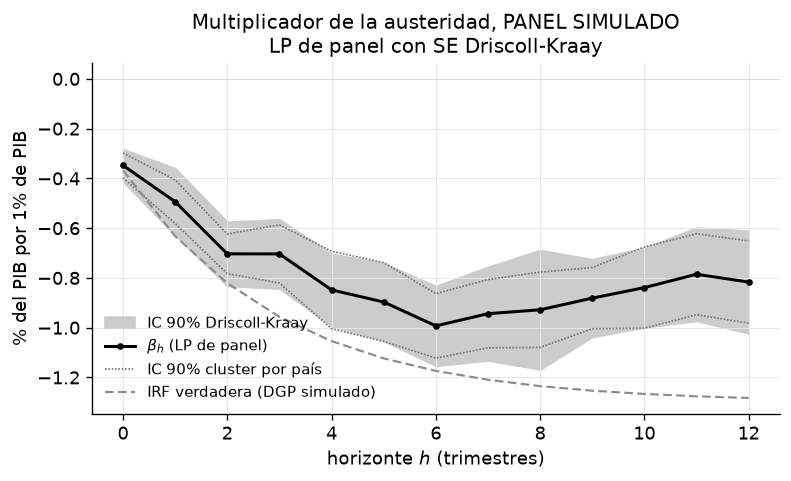

In [5]:
cols = _nbstyle.palette(2)
hh = dk["h"].to_numpy()
fig, ax = plt.subplots(figsize=(7.4, 3.8))
ax.fill_between(hh, dk["lo"], dk["hi"], color="0.80", label="IC 90% Driscoll-Kraay")
ax.plot(hh, dk["beta"], color=cols[0], lw=1.8, marker="o", ms=3, label="$\\beta_h$ (LP de panel)")
ax.plot(hh, cl["lo"], color="0.45", lw=1.0, ls=(0, (1, 1)))
ax.plot(hh, cl["hi"], color="0.45", lw=1.0, ls=(0, (1, 1)), label="IC 90% cluster por país")
ax.plot(hh, [irf_true(h) for h in H], color="0.55", lw=1.3, ls=(0, (4, 2)), label="IRF verdadera (DGP simulado)")
ax.axhline(0, color="0.85", lw=0.6)
ax.set_xlabel("horizonte $h$ (trimestres)"); ax.set_ylabel("% del PIB por 1% de PIB")
ax.set_title("Multiplicador de la austeridad, PANEL SIMULADO\nLP de panel con SE Driscoll-Kraay")
ax.legend(loc="lower left", fontsize=9)
plt.show()

### Lectura
La respuesta estimada es negativa y gana magnitud hasta un **pico de $-0.99$ en $h=6$**;
después **retrocede** ($-0.82$ en $h=12$). Ojo: esa **joroba es de la estimación, no del
DGP** — la columna `IRF_verdadera` es monótona y tiende a $-1.3$. Un $\beta_h$ cercano a
$-1$ significa un **multiplicador cercano a 1** (cada punto del PIB de ajuste cuesta ~1
punto de producto): el orden de magnitud que **Blanchard y Leigh (2013)** documentaron
—multiplicadores de 0.9 a 1.7— frente al $\approx 0.5$ que suponían los pronosticadores.
El capítulo 3 del *WEO* de **octubre de 2010**, que estrenó justamente los datos
narrativos de Devries et al., estimaba $\approx 0.5$ a dos años: ya bastante peor que la
"austeridad expansiva" que sugería el enfoque del CAPB, pero todavía por debajo del 1.
La banda **Driscoll-Kraay** es **en promedio** más ancha que la de cluster (la razón que
imprime la celda anterior es 1.23), aunque **no en todos los horizontes** —en $h=4$ y
$h=10$ el orden se invierte—: es el precio de admitir que los residuos de los países
pueden co-moverse dentro de un mismo trimestre.

> **Qué se aprende aquí y qué no.** El panel es **simulado**, así que lo único que se
> demuestra es **cómo se comporta el estimador** (compara la columna `beta` con
> `IRF_verdadera`) y en qué se distinguen los dos errores estándar. Y la comparación es
> honesta a medias: hasta $h\approx 3$ la estimación sigue de cerca al DGP, pero a
> horizontes largos se queda **corta** ($-0.82$ contra $-1.28$ en $h=12$: una brecha de
> más de tres SE). No es un sesgo del estimador, es **una sola realización** de un panel
> chico —17 países $\times$ 80 trimestres, 114 episodios—: si repites el ejercicio con 60
> países y 200 trimestres, $\beta_{12}$ se acerca a $-1.2$. Lección incómoda y útil: una
> banda al 90 % no cubre el error de una muestra que no da para tantos horizontes.
> La magnitud de la respuesta es, además, la que *pusimos* nosotros en `irf_true`
> (asíntota $-1.3$), no una medición.
>
> El número empírico está en **Slides05**: sobre el panel **anual** 1978-2019 de esos 17
> países (518 observaciones) la misma receta da $\beta_2 = -1.42$ (banda 90 %: $-2.05$ a
> $-0.78$). No es comparable con lo de aquí, y no sólo por ser simulado: en frecuencia
> **trimestral** un ajuste anual de 1 % del PIB se reparte en ~0.25 por trimestre, y el
> $\beta$ **por unidad** se infla. Los CSV reales
> (`dglp_consolidaciones_trimestrales.csv` y `oecd_qna_dglp17.csv`) los distribuye el
> curso con el examen computacional, en la carpeta `data/` de ese paquete; no están en el
> *bundle* de estas lecciones.

## 3. Un índice de postura por texto: Banxico

La incertidumbre y la postura de política **no se observan** directamente: se **leen**.
La tradición de índices por texto (Baker-Bloom-Davis 2016 para EPU; Husted-Rogers-Sun
2020 para incertidumbre de política monetaria) codifica documentos en una señal
numérica. Aquí usamos `banxico_stance_monthly.csv` del bundle, un índice mensual derivado
de los **anuncios de decisión de política monetaria de Banxico** (2000-01 a 2026-04):
- `banxico_direction` $\in\{-1,0,+1\}$: paso de **endurecimiento (+1)** / distensión (−1)
  del mes (108 de los 316 meses traen un paso; el resto va en 0).
- `banxico_stance_signed`: **suma móvil de seis meses** de `banxico_direction` — por eso
  está acotada en $[-6,+6]$, como confirma el `describe` de abajo. **No** es un nivel
  acumulado (el `cumsum` de la dirección sería otra serie, siempre positiva y de rango
  $[1,26]$) y **no** es un LTUI: los léxicos LTUI de `puremacro.narrative` producen otro
  objeto, y construirlo sobre el corpus de anuncios es justo el ejercicio del apéndice de
  **Slides05**.
- `tight_stance_narr` $\in\{0,1\}$: indicador de **régimen restrictivo**; en este archivo
  es exactamente $\mathbf{1}\{\texttt{banxico\_stance\_signed}>0\}$ (134 de 316 meses).

In [6]:
bx = (pd.read_csv(DATA / "banxico_stance_monthly.csv", parse_dates=["date"])
        .sort_values("date").reset_index(drop=True))
print(f"Banxico (texto): {len(bx)} meses, {bx['date'].min():%Y-%m} a {bx['date'].max():%Y-%m}")
print(bx[["banxico_direction", "banxico_stance_signed", "tight_stance_narr"]].describe().round(2).to_string())

# --- ACTIVIDAD SIMULADA (declarada): no hay serie de actividad de México en DATA/*.csv ---
# La calibramos para que un PASO DE ENDURECIMIENTO (banxico_direction=+1) frene la
# actividad con rezago; el índice de postura por texto es REAL, la actividad es simulada.
n = len(bx); paso = bx["banxico_direction"].to_numpy(float)
rng2 = np.random.default_rng(7)
def girf(h):                                       # respuesta "verdadera" de la actividad al endurecimiento
    return -0.45 * (1.0 - np.exp(-(h + 1) / 4.0))  # % de actividad por paso de endurecimiento
tend = np.cumsum(rng2.normal(0.15, 0.30, n))
resp = np.array([sum(girf(t - s) * paso[s] for s in range(t + 1)) for t in range(n)])
actividad = 100.0 + tend + resp + rng2.normal(0, 0.25, n)   # 100*log(índice de actividad) SIMULADO
mx = pd.DataFrame({"act": actividad, "tight": paso})

irf_bx = lp_hac(mx, y="act", x="tight", horizons=range(0, 13), n_lags=3)   # LP de un país, SE HAC
print("\nRespuesta de la actividad SIMULADA a un paso de endurecimiento (LP-HAC).")
print("El índice de postura de Banxico es real; la actividad no. Cifras no citables.")
print(irf_bx[["h", "beta", "se"]].round(3).to_string(index=False))
assert irf_bx["beta"].iloc[4:].min() < 0          # el endurecimiento frena la actividad

Banxico (texto): 316 meses, 2000-01 a 2026-04
       banxico_direction  banxico_stance_signed  tight_stance_narr
count             316.00                 316.00             316.00
mean                0.04                   0.24               0.42
std                 0.58                   2.60               0.49
min                -1.00                  -6.00               0.00
25%                 0.00                  -1.00               0.00
50%                 0.00                   0.00               0.00
75%                 0.00                   2.00               1.00
max                 1.00                   6.00               1.00



Respuesta de la actividad SIMULADA a un paso de endurecimiento (LP-HAC).
El índice de postura de Banxico es real; la actividad no. Cifras no citables.
 h   beta    se
 0 -0.074 0.049
 1 -0.099 0.057
 2 -0.121 0.065
 3 -0.224 0.084
 4 -0.393 0.082
 5 -0.539 0.096
 6 -0.641 0.117
 7 -0.748 0.120
 8 -0.758 0.131
 9 -0.872 0.144
10 -1.042 0.171
11 -1.041 0.195
12 -1.162 0.210


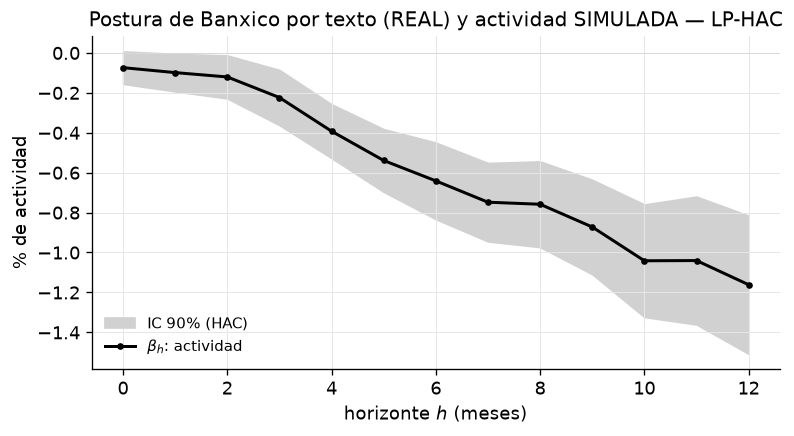

In [7]:
hh = irf_bx["h"].to_numpy()
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.fill_between(hh, irf_bx["lo"], irf_bx["hi"], color="0.82", label="IC 90% (HAC)")
ax.plot(hh, irf_bx["beta"], color="0.0", lw=1.8, marker="o", ms=3, label="$\\beta_h$: actividad")
ax.axhline(0, color="0.85", lw=0.6)
ax.set_xlabel("horizonte $h$ (meses)"); ax.set_ylabel("% de actividad")
ax.set_title("Postura de Banxico por texto (REAL) y actividad SIMULADA — LP-HAC")
ax.legend(loc="lower left", fontsize=9)
plt.show()

### Antes de leer el gráfico: un aviso de unidades
La respuesta estimada llega a $-1.16$ a los 12 meses, **mucho más** que la asíntota de
$-0.45$ que pusimos en `girf`. No es un error de la LP: `banxico_direction` está
fuertemente autocorrelacionada (0.52 al primer rezago, 0.43 al sexto; los pasos vienen en
**rachas**), así que un $+1$ hoy anticipa más $+1$ mañana y el $\beta_h$ recoge el efecto
de **todo el ciclo de alzas que sigue**, no el de un paso aislado. Es la razón por la que
comparar $\beta_h$ entre choques con persistencias distintas es engañoso, y por la que
conviene reportar la respuesta junto con la del propio choque.

### La trampa de la identificación
Este gráfico **no** prueba causalidad — ni siquiera prueba una correlación, porque la
serie de actividad la **fabricamos** nosotros arriba para que el mecanismo se vea. Aun
concediendo datos reales, el diseño fallaría: Banxico **endurece porque** la inflación y la
actividad se recalientan (regla de política): la postura es **endógena**. Una regresión
de actividad sobre la postura mezcla el efecto de la política con la **causalidad
inversa**. Por eso el índice por texto se usa como **proxy/instrumento** de la
*sorpresa* de política —la parte no anticipada por el estado de la economía— y no como
el choque mismo. Y ahí aparece el riesgo de que el instrumento sea **débil**.

## 4. Identificación en panel e instrumentos débiles

Un índice por texto es **ruidoso**: capta la señal de política solo en parte. Si la
correlación entre el instrumento (texto) y el regresor endógeno (sorpresa de política
verdadera) es baja, el estimador IV es **sesgado hacia OLS** y su inferencia estándar
**colapsa**. El diagnóstico es la **F de primera etapa**: reglas de dedo (Staiger-Stock:
$F>10$) y valores críticos formales (Montiel-Olea-Pflueger 2013: F efectiva $>23.1$ para
acotar el sesgo al 10% con un instrumento).

In [8]:
def primera_etapa_F(senal, m=400, seed=1):
    """Primera etapa simulada: endógeno = senal*instrumento + ruido. Devuelve la F."""
    r = np.random.default_rng(seed)
    z = r.normal(0, 1, m)                       # instrumento por texto (estandarizado)
    endog = senal * z + r.normal(0, 1, m)       # sorpresa de política "verdadera"
    Z = np.column_stack([np.ones(m), z])
    b = np.linalg.lstsq(Z, endog, rcond=None)[0]
    u = endog - Z @ b
    s2 = (u @ u) / (m - 2)
    se = np.sqrt(s2 * np.linalg.inv(Z.T @ Z)[1, 1])
    return (b[1] / se) ** 2                      # F = t^2 con un instrumento

senales = np.linspace(0.04, 0.45, 25)
Fs = np.array([primera_etapa_F(s) for s in senales])
for s in (0.05, 0.10, 0.20, 0.40):
    print(f"señal texto->política = {s:0.2f}   ->   F de primera etapa = {primera_etapa_F(s):5.1f}")
assert primera_etapa_F(0.40) > primera_etapa_F(0.05)   # más señal -> instrumento más fuerte

señal texto->política = 0.05   ->   F de primera etapa =   4.9
señal texto->política = 0.10   ->   F de primera etapa =   9.5
señal texto->política = 0.20   ->   F de primera etapa =  23.1
señal texto->política = 0.40   ->   F de primera etapa =  68.4


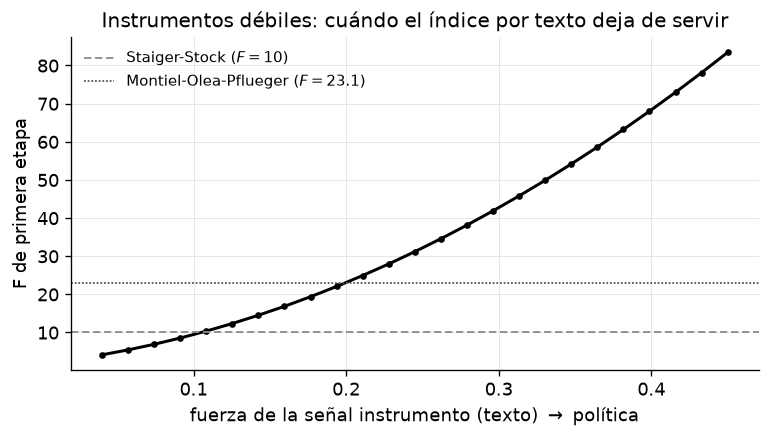

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot(senales, Fs, color="0.0", lw=1.8, marker="o", ms=3)
ax.axhline(10.0, color="0.55", lw=1.1, ls=(0, (4, 2)), label="Staiger-Stock ($F=10$)")
ax.axhline(23.1, color="0.35", lw=1.1, ls=(0, (1, 1)), label="Montiel-Olea-Pflueger ($F=23.1$)")
ax.set_xlabel("fuerza de la señal instrumento (texto) $\\to$ política")
ax.set_ylabel("F de primera etapa")
ax.set_title("Instrumentos débiles: cuándo el índice por texto deja de servir")
ax.legend(loc="upper left", fontsize=9)
plt.show()

### Checklist de identificación en panel
- **Anticipación.** Si las consolidaciones se anuncian antes de ejecutarse, hay
  **pre-tendencias**: los agentes reaccionan en $t-k$ y $\beta_h$ se contamina. Se revisa
  graficando $\beta_h$ para $h<0$ (deben ser ~0), cuidando que el horizonte negativo no
  sea degenerado — véase el ejercicio 2.
- **Choques comunes.** El efecto de tiempo $\tau_t$ absorbe el ciclo global; sin él, un
  año de recesión mundial se confunde con "austeridad generalizada".
- **DK vs cluster.** Con pocos países, el cluster puede subestimar los SE; DK es la
  opción robusta cuando se sospecha **co-movimiento residual** entre países.
- **IV débil.** F baja $\Rightarrow$ usa inferencia robusta a instrumentos débiles
  (Anderson-Rubin) en vez de los errores estándar de IV convencionales.

## 5. Ejercicios
1. Reestima el panel de austeridad con `panel_lp` (cluster) en vez de `panel_lp_dk`.
   Compara el ancho de las bandas al pico. ¿Cuándo importa la diferencia?
2. Añade **placebos adelantados**: `panel_lp_dk` admite horizontes negativos, así que
   basta con `horizons=range(-4, -1), n_lags=1`. ¿Salen los $\beta_h$ cercanos a cero,
   como debería? Dos trampas mecánicas que conviene ver de cerca: en $h=-1$ la variable
   dependiente es $y_{t-1}-y_{t-1}\equiv 0$ (no hay placebo que correr), y en $h=-2$ con
   `n_lags=2` la dependiente $y_{t-2}-y_{t-1}$ es **combinación exacta** de los rezagos de
   control, así que la regresión devuelve $\beta=0$ con SE $=0$. Compruébalo.
3. Sube la probabilidad de episodios a `0.20` y reduce el panel a 6 países. ¿Qué le pasa
   a la razón SE(DK)/SE(cluster)? Repítelo con dos o tres semillas antes de concluir.
4. En el bloque de Banxico, usa `banxico_stance_signed` (la suma móvil de seis meses) en
   vez de `banxico_direction` (el paso del mes) como regresor. ¿Cambia la **forma** de la
   respuesta? ¿Y las **unidades** en las que hay que leer $\beta_h$?
5. En la primera etapa, ¿qué tamaño de muestra `m` hace que una señal de `0.10` cruce
   consistentemente $F=10$? Relaciónalo con el poder del test.

### Soluciones (esquema)
1. `panel_lp` (cluster) suele dar bandas **más angostas**; la brecha con DK crece cuando
   los residuos co-mueven entre países dentro del trimestre (choque global mal absorbido).
2. Con un choque **verdaderamente exógeno** los $\beta_h$ a horizontes negativos deben ser
   ~0, y aquí lo son ($+0.01$ en $h=-4$, $-0.04$ en $h=-3$, $+0.02$ en $h=-2$ con
   `n_lags=1`); un salto pre-choque delataría **anticipación** o endogeneidad. En $h=-1$ no
   hay nada que estimar y en $h=-2$ con `n_lags=2` la colinealidad exacta devuelve
   $\beta=0$ con SE $=0$: un cero que **no** es evidencia de ausencia de pre-tendencia.
3. No pasa lo que uno esperaría. Con 6 países el cluster se apoya en 6 grupos y DK en la
   dimensión temporal: ninguna de las dos asintóticas es la que se supone. En este DGP la
   razón SE(DK)/SE(cluster) **cae por debajo de 1** ($\approx 0.82$ con la semilla de la
   lección) y salta entre ~0.7 y ~1.1 al cambiarla: deja de ser un diagnóstico. DK sigue
   siendo la opción prudente porque su asintótica pide $T$ grande y no $N$ grande, pero
   con 6 países la respuesta honesta es que no hay inferencia fiable.
4. Casi no cambia la forma: `banxico_stance_signed` es la **suma móvil de seis meses** de
   `banxico_direction` (correlación 0.71), es decir el mismo dato pasado por un filtro, y
   la IRF sale igual de creciente y algo más plana al final ($-1.00$ contra $-1.16$ en
   $h=12$). Lo que sí cambia son las **unidades**: $\beta_h$ ya no es "por un paso" sino
   "por un punto de endurecimiento neto acumulado en seis meses", y el regresor se traslapa
   con su propio pasado, así que no es una innovación.
5. F crece aproximadamente como $m\cdot\text{señal}^2$: con señal 0.10 y `m=400` la F
   mediana es ~4 y sólo cruza 10 el 13 % de las veces; con `m=1000` la mediana ronda 10
   (moneda al aire) y hace falta `m` de 2 000 a 3 000 para superarlo con probabilidad
   $\ge 0.9$ — justo el punto de los instrumentos débiles.

## 6. Explora con IA
Prueba esto con el tutor sin conexión (o cualquier asistente de IA):
- "¿Por qué los efectos fijos de tiempo son clave para identificar un multiplicador fiscal en un panel de países?"
- "Explica en dos frases por qué un índice de política por texto puede ser un instrumento débil."

In [10]:
print(tutor("En una frase: ¿por qué Driscoll-Kraay y no cluster cuando hay dependencia "
            "transversal en un panel de países?"))

[tutor sin conexión] No hay ningún motor de LLM local disponible en esta instalación (el tutor es opcional). Puedes instalar uno con `pip install puremacro[local-llm]` más un modelo pequeño (por ejemplo vía Ollama o MLX), o bien usar las indicaciones de la sección «Explora con IA» de esta lección con cualquier asistente de IA.
(motivo: el motor local no está disponible)


**Resumen.** Llevamos la evidencia narrativa al **panel**: estimamos el **multiplicador
de la austeridad** con las consolidaciones *action-based* de Devries et al. (2011) usando
una **LP de panel de dos vías** con **errores Driscoll-Kraay** (`panel_lp_dk`), y la
contrastamos con el cluster por país (`panel_lp`). Después leímos un **índice de postura
por texto** —la postura de **Banxico**, la suma móvil a seis meses de la dirección de sus
anuncios, que no es un LTUI— lo relacionamos con la actividad
(`lp_hac`), y expusimos las dos amenazas centrales: la **identificación en panel**
(anticipación, choques comunes) y los **instrumentos débiles** (F de primera etapa,
umbrales de Staiger-Stock y Montiel-Olea-Pflueger). Con esto cierra el arco de evidencia
narrativa del **mazo Slides05** — todo en `puremacro` (Python puro), ejecutable sin
conexión en tu propia máquina.

**Recuerda el aviso del arranque:** las dos aplicaciones corren sobre datos **simulados y
declarados** (el panel de 17 países y la serie de actividad de México; el índice de
postura de Banxico sí es real). Lo que queda demostrado es que los estimadores funcionan
y en qué se distinguen, no una magnitud del multiplicador fiscal: para eso, Slides05 y
los datos reales del examen computacional.

**Siguiente módulo:** la lección **20 — mercados incompletos, heterogeneidad y HANK**
(`20_heterogeneidad_hank_es`), el bloque de la semana 11 con el mazo Slides06.